# Tracing Agents Using EDD
---

## Evaluation-Driven Development (EDD) 

### Overview

This project is used to create and evalate `spans` related to Agent `traces`.


### Import libraries

In [ ]:
from openai import OpenAI
import pandas as pd
import os
import json
import duckdb
import logging
import pydantic

from pydantic import BaseModel, Field
from IPython.display import Markdown
from typing import Any, Dict, List, Sequence, Union
from dotenv import load_dotenv

import phoenix as px
from phoenix.otel import register
from openinference.instrumentation.openai import OpenAIInstrumentor
from openinference.semconv.trace import SpanAttributes
from opentelemetry.trace import Status, StatusCode
from openinference.instrumentation import TracerProvider

### Initialize OpenAI Client|

In [3]:
load_dotenv() 
AI_API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=AI_API_KEY)

MODEL = "gpt-4o"

###

### Setup Phoenix

**Setup Environment and OpenTelemetry**

In [4]:
PROJECT_NAME = "tracing_agent"
PHOENIX_COLLECTOR_ENDPOINT="http://localhost:6006/v1/traces"

In [ ]:
tracer_provider = register(
    project_name=PROJECT_NAME,
    endpoint=PHOENIX_COLLECTOR_ENDPOINT,
    auto_instrument=True
)


OpenTelemetry Tracing Details
|  Phoenix Project: tracing_agent
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



**Setup OpenAI Instrumentation**

`OpenAIInsrumentor` is used to automatically collect OpenAI LLM calls from code.

In [4]:
OpenAIInstrumentor().instrument(tracer_provider = tracer_provider)

Attempting to instrument while already instrumented


**Get Tracer Object**

the tracer object creats spans from the tracer provider. The tracer object is used to create the LLM calls, tooling, and agent spans. 

In [5]:
tracer = tracer_provider.get_tracer(__name__)

## Tracing Agent 

We will now collect traces from agent:

1. For LLM calls, OpenAIInstrumentor automatically collects **spans** of the type LLM, which containls input and output of an LLM call. 
2. For any other step, manuyal instrumentation will be used to create the sequence of spans in the trace. 


For this agent will will create the following span types:

* **chain** - represents the starting point of a sequence of spans, or a link between spans.
* **tool** - represents the call to an external tool. 
* **agent** - represents the main span that encompases the entire trace -- the main span capturing all calls to LLMs and Tools. 

In [6]:
# define the path to the transactional data
TRANSACTION_DATA_FILE_PATH = 'data/Store_Sales_Price_Elasticity_Promotions_Data.parquet'

**Prompt Template**

In [7]:
SQL_GENERATION_PROMPT = """
Generate an SQL query based on the prompt that follows. Do not reply with anything besides the SQL query.
The prompt is: {prompt}

The available columns are: {columns}
The table name is: {table_name}
"""

**Helper Functions**

In [8]:
def generate_sql_query(prompt: str, columns: list[str], table_name: str) -> str:
    """
    Generate a valid SQL query from a natural language prompt.

    Parameters
    ----------
    prompt : str
        Natural language query.
    columns : list[str]
        Column names in the target table.
    table_name : str
        Name of the table to query.

    Returns
    -------
    str
        Generated SQL query string.
    """
    formatted_prompt = SQL_GENERATION_PROMPT.format(
        prompt=prompt,
        columns=columns,
        table_name=table_name
    )

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    return response.choices[0].message.content.strip()


In [9]:
@tracer.tool()
def lookup_sales_data(prompt: str) -> str:
    """
    Query sales data from a Parquet file using LLM-generated SQL.

    Parameters
    ----------
    prompt : str
        Natural language query.

    Returns
    -------
    str
        Query result as formatted text or an error message.
    """
    try:
        table_name = "sales"

        # Step 1: Load Parquet into DuckDB
        df = pd.read_parquet(TRANSACTION_DATA_FILE_PATH)
        duckdb.sql(f"CREATE TABLE IF NOT EXISTS {table_name} AS SELECT * FROM df")

        # Step 2: Generate SQL and clean output
        sql_query = generate_sql_query(prompt, df.columns.tolist(), table_name)
        sql_query = sql_query.strip().replace("```sql", "").replace("```", "")

        # Step 3: Execute SQL and return results
        result = duckdb.sql(sql_query).df()
        return result.to_string()

    except Exception as e:
        return f"Error accessing data: {e}"


### Data Analysis Tool

In [10]:
DATA_ANALYSIS_PROMPT = """
Analyze the following data: {data}
Your job is to answer the following question: {prompt}
"""

In [11]:
@tracer.tool()
def analyze_sales_data(prompt: str, data: str) -> str:
    """
    Generate an AI-based sales data analysis.

    Formats a prompt using the provided template, data, and instruction,
    then queries a chat-based LLM for an analytical response.

    Args:
        prompt (str): Instruction describing the analysis task.
        data (str): Sales dataset or text input to analyze.

    Returns:
        str: LLM-generated analysis, or a fallback message if empty.
    """
    formatted_prompt = DATA_ANALYSIS_PROMPT.format(data=data, prompt=prompt)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    analysis = response.choices[0].message.content
    return analysis if analysis else "No analysis could be generated"

### Data Visualization Tool

**Step 1:** Create chart configuration: chart type, title, data, labels for x-axis and y-axis (Using an LLM call)

In [12]:
CHART_CONFIGURATION_PROMPT = """
Generate a chart configuration based on this data: {data}
The goal is to show: {visualization_goal}
"""

In [13]:
class VisualizationConfig(BaseModel):
    """
    Configuration schema for chart generation.

    Defines parameters for creating visualizations,
    including chart type, axes, and title.
    """
    chart_type: str = Field(..., description="Type of chart to generate (e.g., bar, line, scatter).")
    x_axis: str = Field(..., description="Column name for the x-axis.")
    y_axis: str = Field(..., description="Column name for the y-axis.")
    title: str = Field(..., description="Chart title.")

In [14]:
@tracer.chain()
def extract_chart_config(data: str, visualization_goal: str) -> dict:
    """Generate chart visualization configuration
    
    Args:
        data: String containing the data to visualize
        visualization_goal: Description of what the visualization should show
        
    Returns:
        Dictionary containing line chart configuration
    """
    formatted_prompt = CHART_CONFIGURATION_PROMPT.format(data=data,
                                                  visualization_goal=visualization_goal)
    
    response = client.beta.chat.completions.parse(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
        response_format=VisualizationConfig,
    )
    
    try:
        # Extract axis and title info from response
        content = response.choices[0].message.content
        
        # Return structured chart config
        return {
            "chart_type": content.chart_type,
            "x_axis": content.x_axis,
            "y_axis": content.y_axis,
            "title": content.title,
            "data": data
        }
    except Exception:
        return {
            "chart_type": "bar", 
            "x_axis": "date",
            "y_axis": "value",
            "title": visualization_goal,
            "data": data
        }

**Step 2:** Generate Python code based on configuration generated on step 1 (Using an LLM call)

In [15]:
CREATE_CHART_PROMPT = """
    Write python code to create a chart based on the configuration that follows.
    Only return the code, for the month of Novemeber, no other text.
    config: {config}
"""

In [16]:
@tracer.chain()
def create_chart(config: dict) -> str:
    """
    Generate Python code for a chart based on the given configuration.

    Args:
        config (dict): Chart parameters including type, axes, and title.

    Returns:
        str: Python code string for rendering the chart.
    """
    formatted_prompt = CREATE_CHART_PROMPT.format(config=config)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    code = response.choices[0].message.content
    code = code.replace("```python", "").replace("```", "")
    code = code.strip()

    return code


In [17]:
@tracer.chain()
def generate_visualization(data: str, visualization_goal: str) -> str:
    """
    Generate Python code for a visualization based on input data and goal.

    Args:
        data (str): Dataset or structured text to visualize.
        visualization_goal (str): Description of the intended visualization.

    Returns:
        str: Python code that creates the requested visualization.
    """
    config = extract_chart_config(data, visualization_goal)
    code = create_chart(config)
    return code

## Defining the Router

### Router Schema    

Now that all skills (tools) have been defined, we move to creating the router. The router will take the original user input and act as the planner. The router will also be responsible for calling tools. After each tool call is completed, the router will evaluate if additional tools should be called. 

In [18]:
# Define tools/functions that can be called by the model
tools = [
    {
        "type": "function",
        "function": {
            "name": "lookup_sales_data",
            "description": "Look up data from Store Sales Price Elasticity Promotions dataset",
            "parameters": {
                "type": "object",
                "properties": {
                    "prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}
                },
                "required": ["prompt"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "analyze_sales_data", 
            "description": "Analyze sales data to extract insights",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {"type": "string", "description": "The lookup_sales_data tool's output."},
                    "prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}
                },
                "required": ["data", "prompt"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "generate_visualization",
            "description": "Generate Python code to create data visualizations",
            "parameters": {
                "type": "object", 
                "properties": {
                    "data": {"type": "string", "description": "The lookup_sales_data tool's output."},
                    "visualization_goal": {"type": "string", "description": "The goal of the visualization."}
                },
                "required": ["data", "visualization_goal"]
            }
        }
    }
]

# Dictionary mapping function names to their implementations
tool_implementations = {
    "lookup_sales_data": lookup_sales_data,
    "analyze_sales_data": analyze_sales_data, 
    "generate_visualization": generate_visualization
}

### Router Logic

The router is composed of a tool calling method and a main loop that runs until the router has completed a trace. 

In [19]:
SYSTEM_PROMPT = """
You are a helpful assistant that can answer questions about the Store Sales Price Elasticity Promotions dataset.
"""

In [20]:
# code for executing the tools returned in the model's response
@tracer.chain()
def handle_tool_calls(tool_calls, messages):
    
    for tool_call in tool_calls:   
        function = tool_implementations[tool_call.function.name]
        function_args = json.loads(tool_call.function.arguments)
        result = function(**function_args)
        messages.append({"role": "tool", 
                         "content": result, 
                         "tool_call_id": tool_call.id})
        
    return messages

In [21]:
def run_agent(messages, system_prompt: str = SYSTEM_PROMPT):
    print("Running agent with messages:", messages)

    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
        
    # Ensure system prompt is present and first
    if not any(
        isinstance(message, dict) and message.get("role") == "system"
        for message in messages
    ):
        sys_prompt = {"role": "system", "content": system_prompt}
        messages.insert(0, sys_prompt)  # put system prompt at the front

    while True:
        print("Making router call to OpenAI")
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools,
        )
        messages.append(response.choices[0].message)
        tool_calls = response.choices[0].message.tool_calls
        print("Received response with tool calls:", bool(tool_calls))

        if tool_calls:
            print("Processing tool calls")
            messages = handle_tool_calls(tool_calls, messages)
        else:
            print("No tool calls, returning final response")
            return response.choices[0].message.content


### Main span

In [ ]:
def start_main_span(messages):
    print("Starting main span with messages:", messages)
    
    with tracer.start_as_current_span(
        "AgentRun", openinference_span_kind="agent"
    ) as span:
        span.set_input(value=messages)
        ret = run_agent(messages) 
        print("Main span completed with return value:", ret)
        span.set_output(value=ret)
        span.set_status(StatusCode.OK)
        return ret


In [23]:
system_prompt = SYSTEM_PROMPT
user_question = "Show me the code for a scatterplot graph of sales by store in Nov 2021, and tell me what trends you see."

In [28]:
result = start_main_span([{"role": "user", 
                           "content": user_question}])

Starting main span with messages: [{'role': 'user', 'content': 'Show me the code for a scatterplot graph of sales by store in Nov 2021, and tell me what trends you see.'}]
Running agent with messages: [{'role': 'user', 'content': 'Show me the code for a scatterplot graph of sales by store in Nov 2021, and tell me what trends you see.'}]
Making router call to OpenAI
Received response with tool calls: True
Processing tool calls
Making router call to OpenAI
Received response with tool calls: True
Processing tool calls
Making router call to OpenAI
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: Here is the Python code you can use to create a scatterplot (bar graph in this case) of total sales by store in November 2021:

```python
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    'Store_Number': [2640, 2090, 4840, 3080, 4070, 2750, 1980, 3300, 660, 770, 2200, 2310, 1870, 3630, 1100,
              

In [29]:
Markdown(result)

Here is the Python code you can use to create a scatterplot (bar graph in this case) of total sales by store in November 2021:

```python
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    'Store_Number': [2640, 2090, 4840, 3080, 4070, 2750, 1980, 3300, 660, 770, 2200, 2310, 1870, 3630, 1100,
                     3190, 2970, 2530, 4400, 1320, 1540, 4730, 990, 4180, 550, 1650, 880, 3410, 1210, 1760,
                     330, 3740, 2420],
    'Total_Sales': [10891.639931, 11617.179888, 19127.169971, 18044.450005, 9161.409921, 16310.409961, 9084.959929,
                    23730.719905, 13041.239901, 9181.769959, 16854.439921, 16611.539945, 17091.849894, 14202.299958,
                    19298.679917, 11934.999961, 31000.569969, 11139.740003, 4390.689987, 19553.789981, 21207.689942,
                    10571.779962, 15101.459945, 10213.819920, 9554.049975, 23186.909958, 17753.769956, 15982.159946,
                    21021.669984, 14598.209948, 12569.599911, 10719.049952, 15234.709888]
}

# Create DataFrame
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df['Store_Number'], df['Total_Sales'], color='skyblue')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.title('Total Sales by Store in November 2021')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```

### Trends Observed:

1. **Top Performing Stores**:
   - *Store 2970* achieved the highest sales with 31,000.57, sharply higher than others, possibly due to special promotions or a high-demand product mix.
   - *Store 3300* also performed well, with 23,730.72 in sales.

2. **Mid-Range Performing Stores**:
   - Several stores had sales between 15,000 and 20,000, indicating consistent performance. Notable among these are Store 1540 and Store 1210.

3. **Low Performing Stores**:
   - *Store 4400* had the lowest sales at 4,390.69, suggesting potential challenges like low foot traffic or ineffective marketing.
   - Store 4070 and Store 1980 also reported low sales figures.

4. **Sales Distribution**:
   - There is a wide range in sales figures, indicating variability in store performance likely due to factors such as location, management, or customer demographics.

5. **Potential Outliers**:
   - The high sales of Store 2970 make it an outlier, suggesting the need for further investigation into its strategies or circumstances driving such performance.

An average sales analysis could help provide benchmarks for normal performance and further highlight stand-out high and low performers.

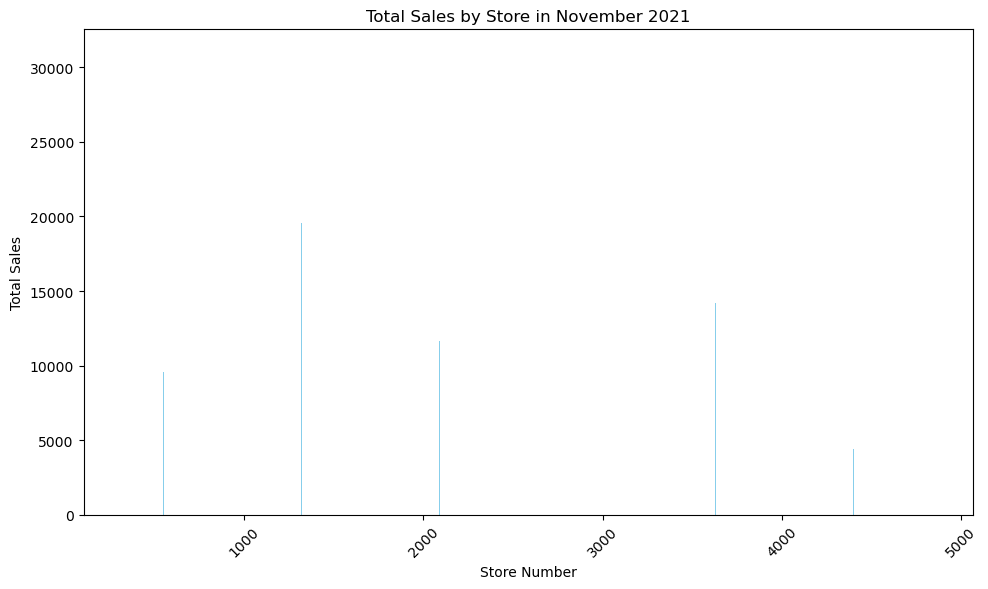

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    'Store_Number': [2640, 2090, 4840, 3080, 4070, 2750, 1980, 3300, 660, 770, 2200, 2310, 1870, 3630, 1100,
                     3190, 2970, 2530, 4400, 1320, 1540, 4730, 990, 4180, 550, 1650, 880, 3410, 1210, 1760,
                     330, 3740, 2420],
    'Total_Sales': [10891.639931, 11617.179888, 19127.169971, 18044.450005, 9161.409921, 16310.409961, 9084.959929,
                    23730.719905, 13041.239901, 9181.769959, 16854.439921, 16611.539945, 17091.849894, 14202.299958,
                    19298.679917, 11934.999961, 31000.569969, 11139.740003, 4390.689987, 19553.789981, 21207.689942,
                    10571.779962, 15101.459945, 10213.819920, 9554.049975, 23186.909958, 17753.769956, 15982.159946,
                    21021.669984, 14598.209948, 12569.599911, 10719.049952, 15234.709888]
}

# Create DataFrame
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(df['Store_Number'], df['Total_Sales'], color='skyblue')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.title('Total Sales by Store in November 2021')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Improving the System
---

In [8]:
IMP_SQL_GENERATION_PROMPT = """
    You are an expert SQL developer. Your task is to generate a syntactically valid SQL query 
    that answers the user’s request based on the provided table schema. 
    You must return **only** the SQL code, formatted cleanly with uppercase SQL keywords.

    Follow these steps internally before producing the final answer:
    1. Analyze the user’s intent.
    2. Identify which columns and filters are relevant.
    3. Construct a valid SQL SELECT statement that answers the query.

    Schema Information:
    - Table Name: {table_name}
    - Available Columns: {columns}

    User Request:
    "{prompt}"

    Guidelines:
    - Return only the SQL query (no explanations, comments, or markdown).
    - Use exact column names as provided — do not invent or rename any.
    - Prefer simple, interpretable SQL (avoid unnecessary nesting or joins).
    - If the user request is ambiguous or impossible, return:
      SELECT "ERROR: Ambiguous or Unsupported Query" AS message;
"""